In [10]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

sys.path.append(str(Path('..').resolve() / 'src'))

from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.dynamic.simulator import DynamicSimulator
from dvrptw_bench.metrics.objective import total_distance
from dvrptw_bench.rl.env_dynamic import MTVRPDynamicEnv
from dvrptw_bench.rl.routefinder_adapter import instance_to_routefinder_td, routefinder_actions_to_solution
from routefinder.envs.mtvrp import MTVRPEnv, MTVRPGenerator
from routefinder.models import RouteFinderBase, RouteFinderPolicy
from routefinder.utils import evaluate as evaluate_routefinder


In [11]:
DATASET_ROOT = Path('../../dataset/solomon_rc100')
OUTPUT_ROOT = Path('../../outputs/paper_dynamic_routefinder')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_CUSTOMERS = 20
MAX_EVAL_INSTANCES = 5
DOD = 0.6
CUTOFF_RATIO = 0.8
EVAL_BUDGET_S = 1.0
EVAL_SEED = 15
EVAL_END_TIME_CLOSENESS = None
NUM_AUGMENT = 8
NORMALIZE_COORDS = True
VARIANT_PRESET = 'vrptw'
MAX_TIME = 10.11

DYNAMIC_MODEL_CKPT = Path('../../notebooks/paper_dynamic/dynamic_attention_routefinder.ckpt')
BASELINE_MODEL_CKPT = Path('../../outputs/20_customers_test_for_hybrid.pt')

if torch.cuda.is_available():
    device = torch.device('cuda')
    accelerator = 'gpu'
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
    accelerator = 'mps'
else:
    device = torch.device('cpu')
    accelerator = 'cpu'
device = torch.device('cpu')

assert BASELINE_MODEL_CKPT.exists(), f'Baseline checkpoint not found: {BASELINE_MODEL_CKPT.resolve()}'
if not DYNAMIC_MODEL_CKPT.exists():
    available = sorted(str(path) for path in OUTPUT_ROOT.glob('*.ckpt'))
    raise FileNotFoundError(
        f'Dynamic env checkpoint not found: {DYNAMIC_MODEL_CKPT.resolve()}\\n'
        f'Set DYNAMIC_MODEL_CKPT to your trained 50-customer dynamic-env checkpoint.\\n'
        f'Available ckpts in {OUTPUT_ROOT.resolve()}: {available}'
    )

model_specs = [
    {
        'name': 'dynamic_env_routefinder',
        'checkpoint': DYNAMIC_MODEL_CKPT,
        'use_dynamic_env': True,
    },
    {
        'name': 'solomon_routefinder_50',
        'checkpoint': BASELINE_MODEL_CKPT,
        'use_dynamic_env': False,
    },
]

instance_paths = find_rc_instances(DATASET_ROOT)
assert instance_paths, f'No RC instances found under {DATASET_ROOT.resolve()}'
if MAX_EVAL_INSTANCES is not None:
    instance_paths = instance_paths[:MAX_EVAL_INSTANCES]
instances = [parse_solomon(path, max_customers=NUM_CUSTOMERS) for path in instance_paths]
print('Device:', device)
print('Instances:', [instance.instance_id for instance in instances])
print('Model specs:', model_specs)


Device: cpu
Instances: ['RC201.txt', 'RC202.txt', 'RC203.txt', 'RC204.txt', 'RC205.txt']
Model specs: [{'name': 'dynamic_env_routefinder', 'checkpoint': PosixPath('../../notebooks/paper_dynamic/dynamic_attention_routefinder.ckpt'), 'use_dynamic_env': True}, {'name': 'solomon_routefinder_50', 'checkpoint': PosixPath('../../outputs/20_customers_test_for_hybrid.pt'), 'use_dynamic_env': False}]


In [12]:
generator = MTVRPGenerator(num_loc=NUM_CUSTOMERS, max_time=MAX_TIME, variant_preset=VARIANT_PRESET)


def load_routefinder_bundle(spec):
    if spec['use_dynamic_env']:
        env = MTVRPDynamicEnv(
            generator=generator,
            check_solution=False,
            dod=0.0,
            cutoff_time=1.0,
            hide_unrevealed_customers=True,
        )
    else:
        env = MTVRPEnv(generator=generator, check_solution=False)

    policy = RouteFinderPolicy(env_name=env.name).to(device)
    model = RouteFinderBase.load_from_checkpoint(
        str(spec['checkpoint']),
        map_location=device,
        env=env,
        policy=policy,
        strict=False,
        weights_only=False,
    )
    model.to(device).eval()
    return {
        'name': spec['name'],
        'env': env,
        'model': model,
        'use_dynamic_env': spec['use_dynamic_env'],
        'checkpoint': spec['checkpoint'],
    }


def solve_snapshot_with_routefinder(bundle, instance, time_limit_s, warm_start=None):
    t0 = time.perf_counter()
    td_kwargs = {'normalize_coords': NORMALIZE_COORDS}
    if bundle['use_dynamic_env']:
        td_kwargs['reveal_times'] = torch.zeros(instance.n_customers + 1, dtype=torch.float32)
        td_kwargs['is_dynamic'] = torch.zeros(instance.n_customers + 1, dtype=torch.bool)

    td = instance_to_routefinder_td(instance, **td_kwargs).to(device)
    td_reset = bundle['env'].reset(td)

    with torch.inference_mode():
        out = evaluate_routefinder(bundle['model'], td_reset.clone(), num_augment=NUM_AUGMENT)
        actions = out.get('best_aug_actions', out.get('best_multistart_actions', out.get('actions')))

    solution = routefinder_actions_to_solution(actions, instance, strategy=bundle['name'])
    solution.total_distance = total_distance(instance, solution)
    solution.solve_time_s = time.perf_counter() - t0
    solution.details.update(
        {
            'num_augment': NUM_AUGMENT,
            'solver_time_limit_s': time_limit_s,
            'warm_start_used': warm_start is not None,
            'checkpoint': str(bundle['checkpoint']),
        }
    )
    return solution


def extract_dynamic_metrics(solution):
    if solution is None:
        return {
            'distance': float('nan'),
            'late_sum': float('nan'),
            'late_count': float('nan'),
            'unserved': float('nan'),
            'served_count': float('nan'),
            'routes': float('nan'),
            'solve_time_s': float('nan'),
            'objective': float('nan'),
        }

    late_sum = float(solution.violations.get('late_sum', 0.0))
    unserved = float(solution.violations.get('unserved', 0.0))
    return {
        'distance': float(solution.total_distance),
        'late_sum': late_sum,
        'late_count': float(solution.violations.get('late_count', 0.0)),
        'unserved': unserved,
        'served_count': float(solution.details.get('served_count', 0.0)),
        'routes': float(len([route for route in solution.routes if route.node_ids])),
        'solve_time_s': float(solution.solve_time_s),
        'objective': float(solution.total_distance) + 100.0 * late_sum + 1000.0 * unserved,
    }


bundles = [load_routefinder_bundle(spec) for spec in model_specs]
print('Loaded bundles:', [(bundle['name'], bundle['checkpoint']) for bundle in bundles])


/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
val_file not set. Generating dataset instead
test_file not set. Generating dataset instead
val_file not set. Generating dataset instead
test_file not set. Generating dataset instead


Loaded bundles: [('dynamic_env_routefinder', PosixPath('../../notebooks/paper_dynamic/dynamic_attention_routefinder.ckpt')), ('solomon_routefinder_50', PosixPath('../../outputs/20_customers_test_for_hybrid.pt'))]


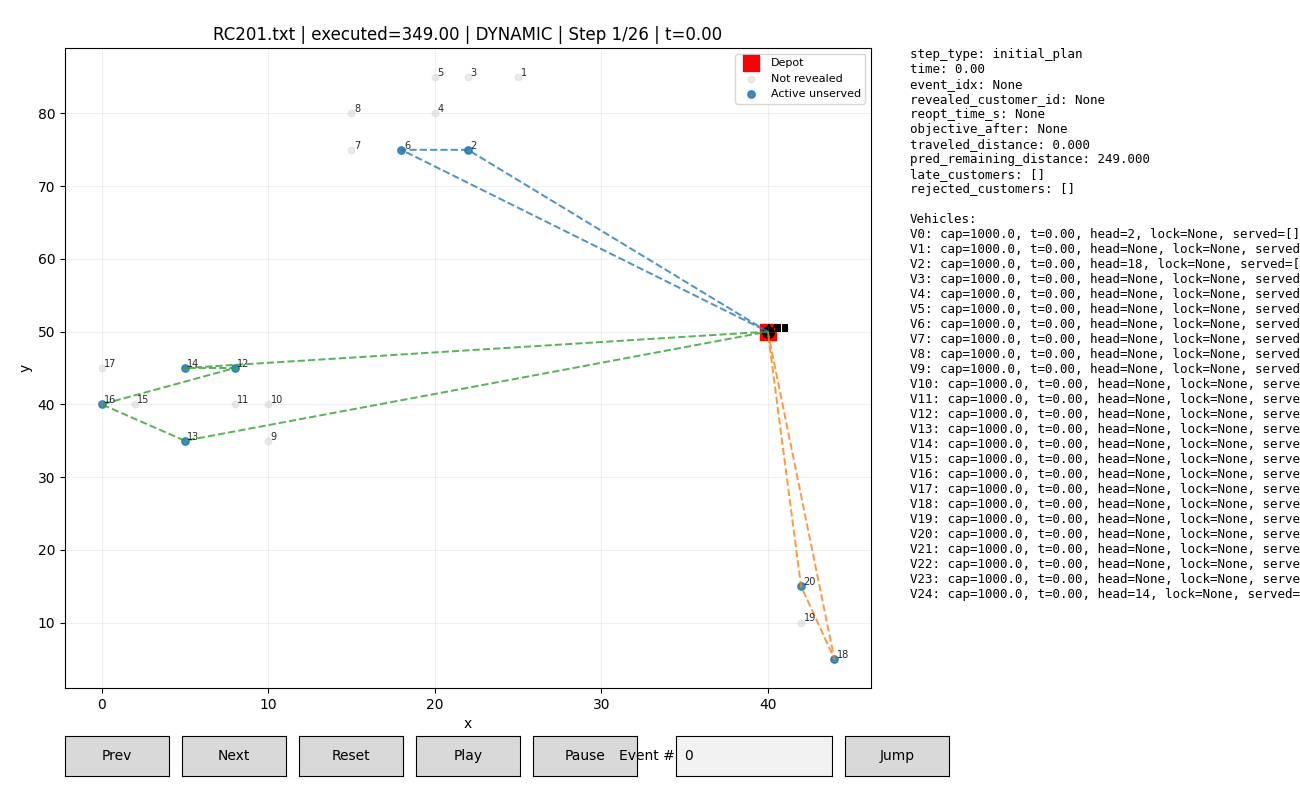

In [14]:
%matplotlib widget
from random import randint

from dvrptw_bench.heuristics.ortools_dynamic import ORToolsDVRPTWSolver
from dvrptw_bench.viz.inspector import inspect_dynamic
from dvrptw_bench.viz.route_plot import plot_routes


# seeds = [randint(0, 1000000) for i in range(10)]

# for seed in seeds:
#     rows = []
#     solutions = {}
#     for instance in instances:
#         for bundle in bundles:
#             sim = DynamicSimulator(instance)
#             solution, events, scenario = sim.run(
#                 lambda instance, time_limit_s, warm_start=None, bundle=bundle: solve_snapshot_with_routefinder(
#                     bundle,
#                     instance,
#                     time_limit_s,
#                     warm_start,
#                 ),
#                 budget_s=EVAL_BUDGET_S,
#                 epsilon=DOD,
#                 seed=seed,
#                 cutoff_ratio=CUTOFF_RATIO,
#                 end_time_closeness=EVAL_END_TIME_CLOSENESS,
#             )
#             solutions[(instance.instance_id, bundle['name'])] = solution
#             metrics = extract_dynamic_metrics(solution)
#             rows.append(
#                 {
#                     'instance_id': instance.instance_id,
#                     'model': bundle['name'],
#                     'checkpoint': str(bundle['checkpoint']),
#                     'dynamic_customers': len(scenario.dynamic_customer_ids),
#                     'reopt_events': len(events),
#                     **metrics,
#                 }
#             )

#     results = pd.DataFrame(rows)
#     summary = results.groupby('model', as_index=False)[['distance', 'late_sum', 'late_count', 'unserved', 'served_count', 'routes', 'solve_time_s', 'objective']].mean()
#     comparison = results.pivot(index='instance_id', columns='model', values='objective')

#     # display(results)
#     # display(summary)
#     # display(comparison)

#     results_path = OUTPUT_ROOT / 'dynamic_env_vs_routefinder_50.csv'
#     summary_path = OUTPUT_ROOT / 'dynamic_env_vs_routefinder_50_summary.csv'
#     plot_path = OUTPUT_ROOT / 'dynamic_env_vs_routefinder_50.png'
#     # results.to_csv(results_path, index=False)
#     # summary.to_csv(summary_path, index=False)

#     plot_df = results[['instance_id', 'model', 'objective']].copy()
#     pivot_plot = plot_df.pivot(index='instance_id', columns='model', values='objective')
#     ax = pivot_plot.plot(kind='bar', figsize=(12, 5))
#     ax.set_title('Dynamic simulator objective by instance')
#     ax.set_ylabel('Objective')
#     ax.set_xlabel('Instance')
#     plt.tight_layout()
#     # plt.savefig(plot_path, dpi=160)
#     # plt.show()

#     print('Saved results to', results_path)
#     print('Saved summary to', summary_path)
#     print('Saved plot to', plot_path)

sim = DynamicSimulator(instances[0])
# inspect_dynamic(instance=instances[0], simulator=sim,solver_fn=lambda instance, time_limit_s, warm_start=None: solve_snapshot_with_routefinder(bundles[0], instance, time_limit_s, warm_start), epsilon=DOD, seed=EVAL_SEED, cutoff_ratio=CUTOFF_RATIO, budget_s=EVAL_BUDGET_S)
inspect_dynamic(instance=instances[0], simulator=sim,solver_fn=lambda instance, time_limit_s, warm_start=None: ORToolsDVRPTWSolver().solve(instance, time_limit_s, warm_start), epsilon=DOD, seed=EVAL_SEED, cutoff_ratio=CUTOFF_RATIO, budget_s=.1)